<a href="https://colab.research.google.com/github/opherdonchin/BayesShortCourse/blob/main/sleep/solved/06_lognormal_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sleep deprivation 6 — Lognormal regression

Notebook 5's Gaussian model reproduced the overall distribution of reaction times reasonably well, so this notebook is not repairing a failed fit. But a Gaussian likelihood does not know that reaction times must be positive: Notebook 5's prior predictive bands reached below zero. Reaction times are strictly positive and typically right-skewed, which makes them a natural candidate for multiplicative rather than additive variation.

Here we replace the Gaussian likelihood with a **lognormal** likelihood, which has positive support and right skew. To isolate that one change, we return to the population-level regression of Notebook 1: one intercept, one slope, and no participant-specific parameters.

The purpose of this notebook is to see how changing the likelihood changes the scale on which parameters and priors live, and therefore how the fitted model is interpreted.

## Setup

This course pins PyMC and the modular ArviZ packages for reproducibility because their APIs can change across major versions.

In [1]:
%pip install -q \
    "pandas==2.2.3" \
    "pymc==6.3.2" \
    "arviz-base==1.3.0" \
    "arviz-stats==1.3.2" \
    "arviz-plots[matplotlib]==1.3.1"

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from pymc.stats.log_density import compute_log_density
import pymc as pm
import arviz_base as azb
import arviz_plots as azp
import arviz_stats as azs

RANDOM_SEED = 20260924
azp.style.use("arviz-variat")

print("PyMC:", pm.__version__)
print("arviz-base:", azb.__version__)
print("arviz-plots:", azp.__version__)
print("arviz-stats:", azs.__version__)

PyMC: 6.3.2
arviz-base: 1.3.0
arviz-plots: 1.3.1
arviz-stats: 1.3.2


## Data

The original study contains two adaptation/training days followed by a baseline measurement and then seven nights of severe sleep restriction. You can read about the original study here: [Belenky J Sleep Res. 2003](https://doi.org/10.1046/j.1365-2869.2003.00337.x)

Following the chapter, we drop original days 0–1 and subtract 2 from the remaining day number. Therefore **`Days = 0` is the baseline measurement before sleep deprivation begins**.

In [3]:
DATA_URL = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/lme4/sleepstudy.csv"

sleep = pd.read_csv(DATA_URL).drop(columns="rownames")
sleep = sleep.loc[sleep["Days"] >= 2].copy()
sleep["Days"] = sleep["Days"] - 2
sleep["Subject"] = sleep["Subject"].astype(str)
sleep = sleep.reset_index(drop=True)

print(f"{sleep['Subject'].nunique()} participants, {len(sleep)} observations")
print(f"Days: {sleep['Days'].min()} to {sleep['Days'].max()}")
sleep.head()

18 participants, 144 observations
Days: 0 to 7


,Reaction,Days,Subject
0,250.8006,0,308
1,321.4398,1,308
2,356.8519,2,308
3,414.6901,3,308
4,382.2038,4,308


### Plotting helpers

The participant plotting helper from the previous notebooks is supplied. Because this notebook's model has no participant-specific parameters, we also use `plot_population`, which draws a single population-level trend against days together with all observations.

In [4]:
LM_VISUALS = {
    "pe_line": {"color": "C1"},
    "ci_band": {"color": "C0"},
    "observed_scatter": {"color": "black", "alpha": 1, "zorder": 3, "s": 10},
}

PARTICIPANT_DAY = xr.Coordinates.from_pandas_multiindex(
    pd.MultiIndex.from_frame(
        sleep[["Subject", "Days"]],
        names=["participant", "day"],
    ),
    "obs_id",
)

def plot_population(dt, var, group="posterior"):
    """Single-panel trend of `var` against days, with all raw observations."""
    pc = azp.plot_lm(
        dt,
        x="days",
        y=var,
        y_obs="y",
        group=group,
        plot_dim="obs_id",
        ci_prob=(0.50, 0.90),
        ci_kind="hdi",
        point_estimate="mean",
        smooth=False,
        figure_kwargs={"figsize": (7, 4)},
        visuals={**LM_VISUALS, "xlabel": False, "ylabel": False},
    )

    pc.facet_map("labelled_x", text="Days of sleep deprivation")
    pc.facet_map("labelled_y", text="Reaction time (ms)")
    pc.add_legend("prob", title="HDI")
    return pc

def plot_participants(dt, group, var, coords=None):
    """One panel per participant, optionally restricted with ArviZ coords."""
    def reshape(ds):
        return ds.assign_coords(PARTICIPANT_DAY).unstack("obs_id")

    panels = xr.DataTree.from_dict({
        group: reshape(dt[group].to_dataset()),
        "observed_data": reshape(dt["observed_data"].to_dataset()),
        "constant_data": reshape(dt["constant_data"].to_dataset()),
    })

    pc = azp.plot_lm(
        panels,
        x="days",
        y=var,
        y_obs="y",
        group=group,
        plot_dim="day",
        coords=coords,
        ci_prob=(0.50, 0.90),
        ci_kind="hdi",
        point_estimate="mean",
        smooth=False,
        cols=["participant"],
        col_wrap=6,
        figure_kwargs={"figsize": (11, 5.5), "sharex": True, "sharey": True},
        visuals={**LM_VISUALS, "xlabel": False, "ylabel": False},
    )

    pc.add_legend("prob", title="HDI")
    fig = pc.get_viz("figure")
    fig.supxlabel("Days of sleep deprivation")
    fig.supylabel("Reaction time (ms)")
    return pc

## 1. Priors on the wrong scale

### 1.1 The lognormal regression model

The model keeps the linear predictor of Notebook 1 but replaces the Normal likelihood with a lognormal one:

$$
y_i \sim \operatorname{LogNormal}(\mu_{y,i}, sd_y)
$$

$$
\mu_{y,i} = b_0 + b_1\,\mathrm{days}_i
$$

Equivalently, $\log y_i \sim \operatorname{Normal}(\mu_{y,i}, sd_y)$: the familiar linear regression now describes **log** reaction time.

### 1.2 What does `mu_y` represent in a lognormal likelihood?

In Notebook 1, `b0` was the baseline reaction time in milliseconds, and its prior was centered at 250. What baseline reaction time would $b_0 = 250$ imply in this model?

`mu_y` is the mean of **log** reaction time, so $e^{\mu_y}$ is the median reaction time in milliseconds. A value of $b_0 = 250$ would imply a median baseline reaction time of $e^{250} \approx 10^{108}$ ms, vastly longer than the age of the universe (about $4 \times 10^{20}$ ms).

### 1.3 The mis-scaled model

The model is supplied. It reuses the prior constants from Notebook 1 unchanged; only the likelihood has changed to `pm.LogNormal`.

In [5]:
coords = {"obs_id": np.arange(len(sleep))}

# Prior constants from Notebook 1, reused unchanged (elicited in milliseconds)
mu_b0 = 250
sd_b0 = 100

mu_b1 = 0
sd_b1 = 20

mu_sd_y = 50

with pm.Model(coords=coords) as bad_model:
    days = pm.Data("days", sleep["Days"].to_numpy(), dims="obs_id")

    b0 = pm.Normal("b0", mu=mu_b0, sigma=sd_b0)
    b1 = pm.Normal("b1", mu=mu_b1, sigma=sd_b1)
    sd_y = pm.Exponential("sd_y", scale=mu_sd_y)

    mu_y = pm.Deterministic("mu_y", b0 + b1 * days, dims="obs_id")

    y = pm.LogNormal(
        "y",
        mu=mu_y,
        sigma=sd_y,
        observed=sleep["Reaction"].to_numpy(),
        dims="obs_id",
    )

### 1.4 Generate prior predictive reaction times from the mis-scaled model.

Draw 500 samples from the prior predictive distribution for `y` in `bad_model` and store them as `bad_prior`.

In [6]:
with bad_model:
    bad_prior = pm.sample_prior_predictive(
        draws=500,
        var_names=["y"],
        random_seed=RANDOM_SEED,
    )

Sampling: [b0, b1, sd_y, y]


### 1.5 Summarize the prior predictive reaction times.

These values are far too extreme to plot usefully on a millisecond axis, so the summary code is supplied. It reports the median prior predictive reaction time and the share of draws between 50 ms and 1 s.

In [7]:
y_bad = bad_prior["prior_predictive"]["y"]
plausible = (y_bad > 50) & (y_bad < 1000)

print(f"Median prior predictive reaction time: {y_bad.median().item():.2g} ms")
print(f"Share of draws between 50 ms and 1 s: {plausible.mean().item():.1%}")

Median prior predictive reaction time: 2.9e+107 ms
Share of draws between 50 ms and 1 s: 0.2%


### 1.6 Do these prior predictions meet the criteria established in Notebook 1?

Recall the three criteria: predicted reaction times should not routinely be physically impossible, reaction times near baseline should mostly occupy a broadly plausible range, and the model should allow substantial change across the seven days without routinely generating absurd trajectories.

No. All three criteria fail. The median prior predictive reaction time is astronomically large, more than $10^{100}$ ms, and only about **0.2%** of draws fall between 50 ms and 1 s.

The priors were reasonable in Notebook 1, and their numbers have not changed. What changed is the scale they act on: `b0`, `b1`, and `sd_y` now describe **log** reaction time, so the same values mean something completely different.

## 2. Priors on the log scale

### 2.1 What prior should we use for baseline reaction time on the log scale?

As in Notebook 1, we are fairly sure that almost all alert reaction times are between 50 and 450 ms. Now $e^{b_0}$ is the median baseline reaction time, so this range must first be converted to the log scale. What Normal distribution for $b_0$ puts approximately 95% of its probability between $\log(50)$ and $\log(450)$?

$\log(50) \approx 3.91$ and $\log(450) \approx 6.11$. The midpoint is about 5.0, and the half-width is about $1.1 \approx 2(0.55)$, so

$$
b_0 \sim \operatorname{Normal}(5, 0.55).
$$

On the millisecond scale the center, $e^{5} \approx 150$ ms, is the geometric midpoint $\sqrt{50 \times 450} = 150$ ms, not the arithmetic midpoint of 250 ms: an interval that is symmetric on the log scale is asymmetric in milliseconds.

### 2.2 What prior should we use for the daily effect on the log scale?

`b1` is now the change in log reaction time per day, so each day multiplies the median reaction time by $e^{b_1}$. As in Notebook 1, we put aside our knowledge that sleep deprivation is unlikely to speed responses and use a symmetric Normal prior centered at zero.

Suppose we regard almost all daily multiplicative changes between ×0.67 and ×1.5 (from about a one-third decrease to a 50% increase per day) as plausible. What Normal distribution expresses that assumption?

$\log(0.67) \approx -0.40$ and $\log(1.5) \approx 0.41$, so the range is approximately $0 \pm 2(0.2)$ on the log scale:

$$
b_1 \sim \operatorname{Normal}(0, 0.2).
$$

For small values, $b_1$ is approximately the proportional change per day: $b_1 = 0.1$ is roughly a 10% change per day.

### 2.3 What prior should we use for the residual variation on the log scale?

`sd_y` is now the standard deviation of log reaction time around the regression line. It has no units: one residual standard deviation multiplies or divides the median reaction time by $e^{sd_y}$.

Suppose we use an Exponential prior and expect its mean to be 1/3. What should its scale parameter be, and what multiplicative spread does $sd_y = 1/3$ represent?

For an Exponential distribution parameterized by its scale, the mean equals the scale, so

$$
sd_y \sim \operatorname{Exponential}(\mathrm{scale}=1/3).
$$

A value of $sd_y = 1/3$ means that one residual standard deviation multiplies or divides the median reaction time by about $e^{1/3} \approx 1.4$.

### 2.4 Store the log-scale prior constants.

Assign the values from Questions 2.1–2.3 to `mu_b0`, `sd_b0`, `mu_b1`, `sd_b1`, and `mu_sd_y`. These are the same names used for the mis-scaled model; only their values, and the scale they act on, change.

In [8]:
mu_b0 = 5
sd_b0 = 0.55

mu_b1 = 0
sd_b1 = 0.2

mu_sd_y = 1 / 3

### 2.5 Build the lognormal model with the log-scale priors.

Use the same structure and `coords` as the mis-scaled model, with the constants from Question 2.4, and call the model `model`. Also add the expected reaction time in milliseconds as a `pm.Deterministic` named `mean_rt`:

$$
\mathrm{E}[y_i] = \exp\!\left(\mu_{y,i} + \tfrac{1}{2}\,sd_y^2\right).
$$

Name the model variables `days`, `b0`, `b1`, `sd_y`, `mu_y`, `mean_rt`, and `y`.

In [9]:
with pm.Model(coords=coords) as model:
    days = pm.Data("days", sleep["Days"].to_numpy(), dims="obs_id")

    b0 = pm.Normal("b0", mu=mu_b0, sigma=sd_b0)
    b1 = pm.Normal("b1", mu=mu_b1, sigma=sd_b1)
    sd_y = pm.Exponential("sd_y", scale=mu_sd_y)

    mu_y = pm.Deterministic("mu_y", b0 + b1 * days, dims="obs_id")

    # Expected reaction time in milliseconds
    mean_rt = pm.Deterministic(
        "mean_rt",
        pm.math.exp(mu_y + sd_y**2 / 2),
        dims="obs_id",
    )

    y = pm.LogNormal(
        "y",
        mu=mu_y,
        sigma=sd_y,
        observed=sleep["Reaction"].to_numpy(),
        dims="obs_id",
    )

### 2.6 Generate prior predictive reaction times.

Draw 500 samples from the prior predictive distribution for `y` and store them as `prior`.

In [10]:
with model:
    prior = pm.sample_prior_predictive(
        draws=500,
        var_names=["y"],
        random_seed=RANDOM_SEED,
    )

Sampling: [b0, b1, sd_y, y]


### 2.7 Plot the prior predictive reaction times.

Use the supplied `plot_participants` function.

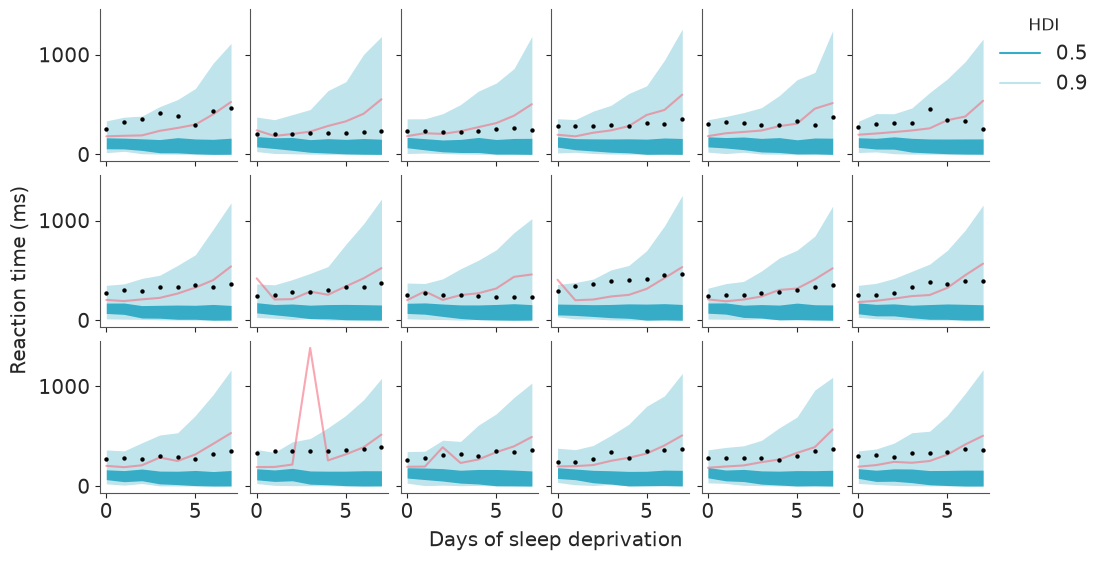

In [11]:
plot_participants(prior, "prior_predictive", "y")
plt.show()

### 2.8 Do these prior predictions meet the criteria established in Notebook 1?

Judge support, baseline scale, and changes across days.

Broadly, but with an important warning. The scale mistake is gone: every prediction is a positive reaction time, and at baseline the 90% bands span roughly 20–350 ms, mostly a plausible range.

Because `b1` acts multiplicatively, however, uncertainty about it compounds across days: by day 7 the 90% bands stretch from near zero to about a second. Positive support rules out negative reaction times, not implausible ones; responses of a few milliseconds are still physically impossible. Like the priors in Notebook 1, these are deliberately broad teaching priors, and we proceed while keeping that limitation in mind.

### 2.9 Why does the mean line sit above the 50% band?

The orange line is the prior predictive mean; the blue bands are HDIs.

The prior predictive distribution is **right-skewed**. Its long upper tail pulls the mean above most of the probability mass, while an HDI covers the most probable values, which lie lower. As the spread grows across days, so does the skew: the 50% band sinks toward zero while the mean rises. A few very large draws also make the mean line jumpy at later days.

Both displays are correct; they summarize different features of a skewed distribution.

## 3. Fit and diagnose the model

### 3.1 Fit the model.

Use the same sampling settings as before: 1000 posterior draws in each of 4 chains after 1500 tuning draws.

In [12]:
with model:
    idata = pm.sample(
        draws=1000,
        tune=1500,
        chains=4,
        random_seed=RANDOM_SEED,
    )

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 2 jobs)


NUTS: [b0, b1, sd_y]


Output()

Sampling 4 chains for 1_500 tune and 1_000 draw iterations (6_000 + 4_000 draws total) took 3 seconds.


### 3.2 Check the sampling diagnostics.

Count divergences, summarize `b0`, `b1`, and `sd_y` with a 90% HDI, and inspect their trace/distribution plots.

In [13]:
print("Divergences:", int(idata["sample_stats"]["diverging"].sum().item()))

azs.summary(
    idata,
    var_names=["b0", "b1", "sd_y"],
    ci_prob=0.90,
    ci_kind="hdi",
    round_to=2,
)

Divergences: 0


,mean,sd,hdi90_lb,hdi90_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
b0,5.59,0.03,5.54,5.63,1964.11,1951.06,1.0,0.0,0.0
b1,0.04,0.01,0.03,0.05,2015.23,1976.88,1.0,0.0,0.0
sd_y,0.17,0.01,0.15,0.18,2455.83,2136.25,1.0,0.0,0.0


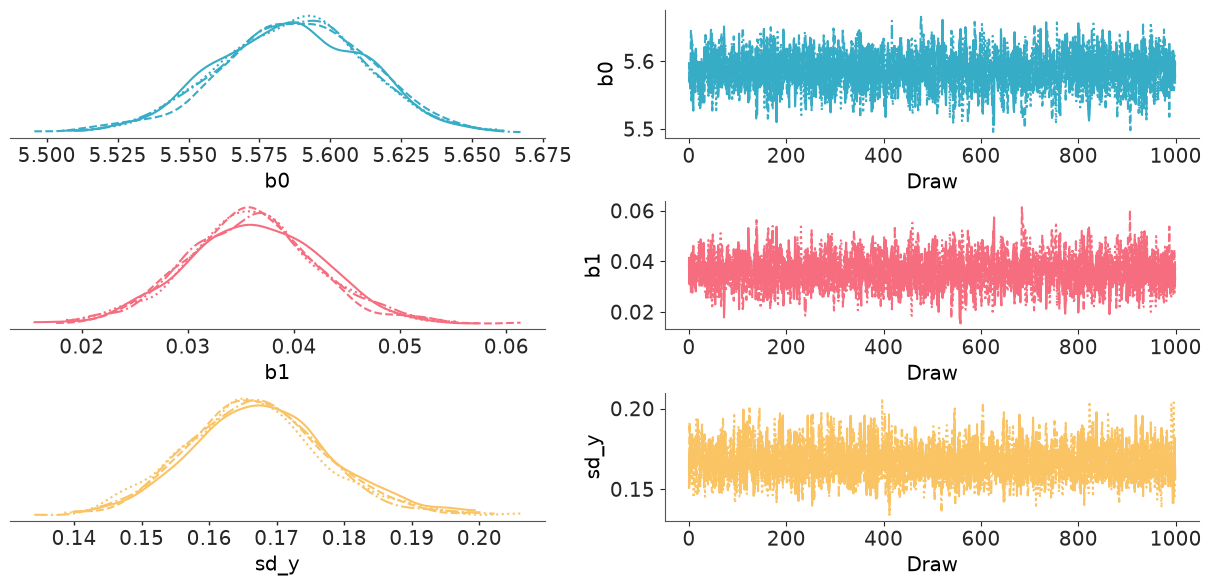

In [14]:
azp.plot_trace_dist(idata, var_names=["b0", "b1", "sd_y"]);

### 3.3 Do the diagnostics meet the criteria established in Notebook 1?

Use the same criteria: no divergences, R-hat close to 1, adequate bulk and tail ESS, and well-mixed traces.

Yes. There are no divergences, R-hat is 1.00 for `b0`, `b1`, and `sd_y`, their bulk and tail ESS values are all well above 1,000, and the traces show well-mixed chains. The default sampler settings are sufficient for this model.

## 4. Population effect under a lognormal likelihood

### 4.1 Which variable is the expected reaction time in milliseconds, and how does it differ from `mu_y`?

`mean_rt`. `mu_y` is not in milliseconds at all: it is the mean of **log** reaction time, and $e^{\mu_y}$ is the *median* reaction time. Because the lognormal distribution is right-skewed, its mean is larger than its median, which is why `mean_rt` is $\exp(\mu_y + sd_y^2/2)$ rather than $e^{\mu_y}$.

With a residual scale as small as the fitted `sd_y` (about 0.17), the mean is only about 1.5% above the median, but the gap grows quickly for more variable outcomes.

### 4.2 Plot the posterior population-average expected reaction time.

Use the supplied `plot_population` function to plot the posterior distribution of `mean_rt` across days.

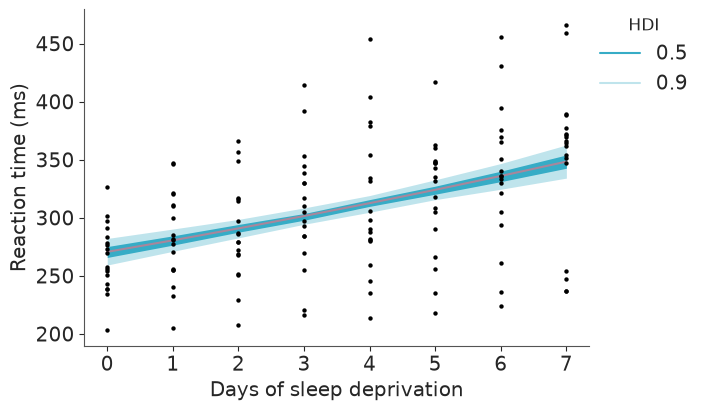

In [15]:
plot_population(idata, "mean_rt")
plt.show()

### 4.3 What uncertainty do the bands represent?

Is the uncertainty shown by the bands in this plot uncertainty about the mean or uncertainty about future reaction times?

It is uncertainty about the **population-average expected reaction time** `mean_rt`. It does not include the residual variation of individual reaction times around that mean, which is why most observations lie outside the bands.

### 4.4 How does the lognormal model express the daily effect of sleep deprivation?

Use the posterior summary of `b1` from Question 3.2. What does $e^{b_1}$ mean for reaction time?

**Multiplicatively.** `b1` is the daily change in log reaction time, so each day multiplies the median, and the mean, reaction time by $e^{b_1}$. The 90% HDI for `b1` is approximately **0.03–0.05**, that is, about **3–5% slowing per day**.

Because the change is proportional, the increase in milliseconds per day grows as reaction times lengthen, whereas the `b1` of Notebook 1 was a constant number of milliseconds per day.

## 5. Predictive consequences of the likelihood

### 5.1 Generate and plot posterior predictive reaction times.

Generate replicated values of `y` from the fitted model, add them to `idata`, and compare them with the observations using `plot_participants`.

Sampling: [y]


Output()

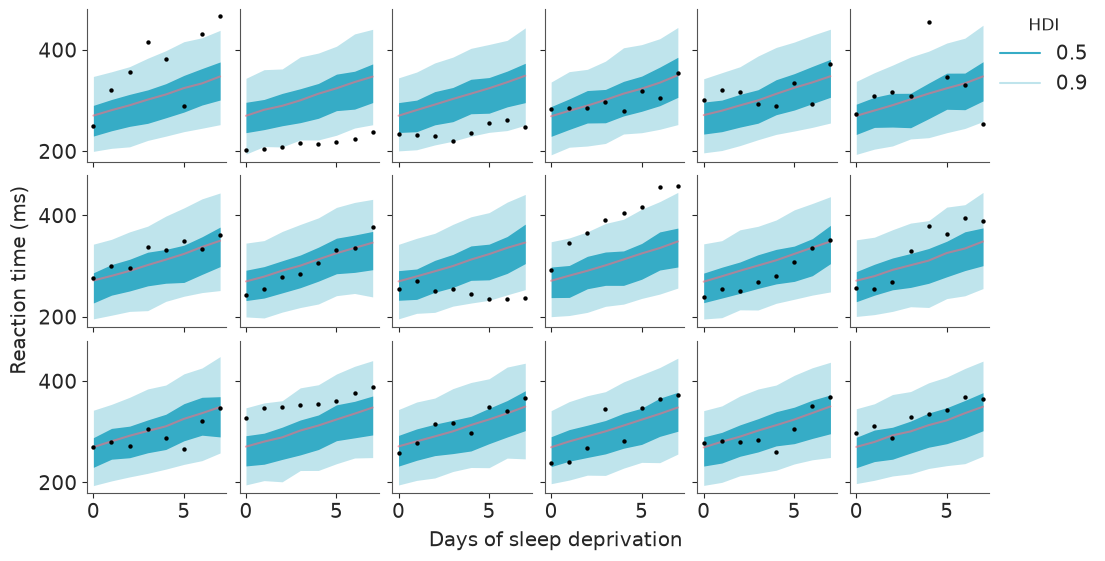

In [16]:
with model:
    pm.sample_posterior_predictive(
        idata,
        var_names=["y"],
        extend_inferencedata=True,
        random_seed=RANDOM_SEED,
    )

plot_participants(idata, "posterior_predictive", "y")
plt.show()

### 5.2 What is added when we move from `mean_rt` to posterior predictive `y`?

Residual observation-level variation controlled by `sd_y`. In a lognormal model this variation is multiplicative: its size in milliseconds is proportional to the expected reaction time, so the predictive bands are wider where reaction times are longer.

### 5.3 Does the model reproduce the participant-level data?

Apply the posterior predictive criteria from Notebook 1: participants' overall levels, changes across days, and residual variation, emphasizing discrepancies that persist across a participant's observations. Also check positivity and the shape of the bands.

Not fully. Every replicated reaction time is positive, and the bands are somewhat wider on later days, when reaction times are longer. But the main failure from Notebook 1 remains: with one population intercept and one population slope, whole participants sit systematically above or below the bands, and participants whose reaction times barely change are not distinguished from those who slow down sharply.

### 5.4 What would indicate adequate fit in an ECDF check?

The participant panels check conditional trajectories. We now pool all observations and ask a different question: does the lognormal likelihood reproduce the overall distribution of reaction times?

As in Notebook 5, the observed ECDF should be broadly consistent with the posterior-predictive ECDFs across the whole distribution, without a persistent systematic displacement, particularly in the upper tail, where right skew would show.

### 5.5 Plot the observed and posterior-predictive ECDFs.

Use `azp.plot_ppc_dist` with `kind="ecdf"`.

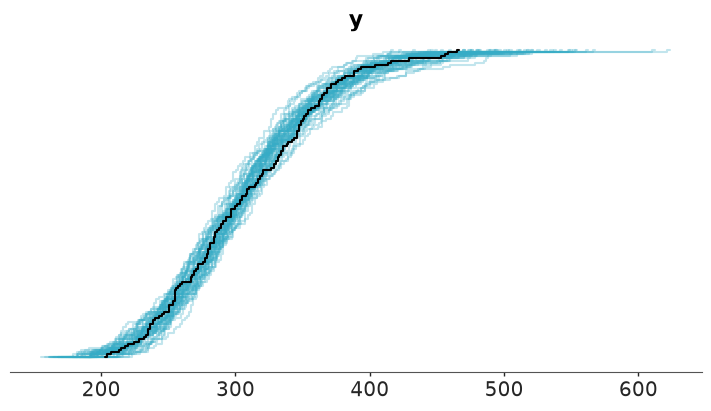

In [17]:
azp.plot_ppc_dist(
    idata,
    var_names=["y"],
    kind="ecdf",
    figure_kwargs={"figsize": (7, 4)},
);

### 5.6 Does the lognormal likelihood reproduce the overall distribution, and does this differ from what Notebook 5 found for the Gaussian likelihood?

Broadly, yes. The observed ECDF lies close to the posterior-predictive ECDFs, with no large persistent displacement in either tail.

This does not differ meaningfully from Notebook 5, which reached the same verdict for its Gaussian model. That model also had participant-specific intercepts and slopes, so the comparison is not like-for-like, but on these data the marginal check does not decisively favor either likelihood.

What the lognormal likelihood changes is structural rather than a repaired misfit: reaction times are positive by construction, residual variation is multiplicative, and every parameter and prior now lives on the log scale.

## 6. Sensitivity on the log scale

### 6.1 Why check prior sensitivity here?

The priors in this notebook were chosen on the log scale, where intuitions are weakest, and Section 1 showed how badly a scale mistake can go.

Power-scaling sensitivity, introduced in Notebook 1, asks whether slightly strengthening or weakening these priors would move the posterior substantially.

### 6.2 Prepare the information required for power-scaling.

The bookkeeping code is supplied.

In [18]:
with model:
    pm.compute_log_likelihood(idata)
    compute_log_density(
        idata,
        model=model,
        kind="prior",
        extend_inferencedata=True,
    )

Output()

Output()

### 6.3 Calculate prior sensitivity.

Use `azs.psense_summary` for `b0`, `b1`, and `sd_y`.

In [19]:
azs.psense_summary(
    idata,
    var_names=["b0", "b1", "sd_y"],
)

,prior,likelihood,diagnosis
b0,0.007,0.108,✓
b1,0.006,0.111,✓
sd_y,0.005,0.123,✓


### 6.4 Are the conclusions sensitive to the log-scale priors?

Recall that ArviZ uses 0.05 as a screening threshold for prior sensitivity. Does the `diagnosis` column flag any parameter?

No. The prior sensitivities for `b0`, `b1`, and `sd_y` are all far below 0.05, and the `diagnosis` column flags none of them. Once they are expressed on the correct scale, these broad priors leave the posterior driven by the data.

## 7. Summary

### 7.1 What has this notebook shown?

Summarize what replacing the Gaussian likelihood with a lognormal one changed for the priors, for the interpretation of the parameters, for the predictive checks, and for prior sensitivity.

- **Priors.** Changing the likelihood changed the scale of every parameter. Notebook 1's priors, reused unchanged, implied median reaction times of more than $10^{100}$ ms, and the prior predictive check exposed this immediately. Expressing similar beliefs on the log scale gave $b_0 \sim \operatorname{Normal}(5, 0.55)$, $b_1 \sim \operatorname{Normal}(0, 0.2)$, and $sd_y \sim \operatorname{Exponential}(\mathrm{scale}=1/3)$, whose predictions are positive and broadly plausible, although very permissive late in the week.
- **Interpretation.** `mu_y` is the mean of log reaction time, not an expected reaction time; the expected reaction time in milliseconds is `mean_rt`. The daily effect of sleep deprivation is multiplicative: about 3–5% slowing per day.
- **Predictive checks.** Predicted reaction times are always positive, and the pooled distribution of reaction times is reproduced about as well as by the Gaussian likelihood in Notebook 5. The participant-level check shows the same mismatch as in Notebook 1: a model with only population-level parameters cannot reproduce persistent differences between participants.
- **Sampling and sensitivity.** Sampling was clean with the default settings, and the log-scale priors had negligible influence on the posterior.